
# K-Nearest Neighbors (KNN)
---
### Author :  Muhammad Ali Saagar

**Python Developer • Data Science • AI/ML Engineer**

#### 🔗 Connect With Me

[![GitHub](https://img.shields.io/badge/GitHub-Profile-181717?style=for-the-badge\&logo=github)](https://github.com/AliMuhammad78)
[![LinkedIn](https://img.shields.io/badge/LinkedIn-Profile-0A66C2?style=for-the-badge\&logo=linkedin)](https://www.linkedin.com/in/muhammad-ali-91294a290)
[![Kaggle](https://img.shields.io/badge/Kaggle-Profile-20BEFF?style=for-the-badge\&logo=kaggle)](https://www.kaggle.com/ali98muhammad45)
[![YouTube](https://img.shields.io/badge/YouTube-Channel-FF0000?style=for-the-badge\&logo=youtube)](https://www.youtube.com/@TechyBits20121)
[![Email](https://img.shields.io/badge/Email-Contact-D14836?style=for-the-badge\&logo=gmail)](mailto:alisaagar86@gmail.com)


### Acknowledgement

> Most of the examples in this notebook are based on the excellent tutorials by **Dr. Muhammad Aammar Tufail (Codanics)**. I sincerely thank him for sharing his knowledge and practical examples.

 [![GitHub](https://img.shields.io/badge/GitHub-Profile-181717?style=for-the-badge\&logo=github)](https://github.com/AammarTufail)
[![LinkedIn](https://img.shields.io/badge/LinkedIn-Profile-0A66C2?style=for-the-badge\&logo=linkedin)](https://www.linkedin.com/in/dr-muhammad-aammar-tufail-02471213b/)
[![Kaggle](https://img.shields.io/badge/Kaggle-Profile-20BEFF?style=for-the-badge\&logo=kaggle)](https://www.kaggle.com/muhammadaammartufail)
[![YouTube](https://img.shields.io/badge/YouTube-Channel-FF0000?style=for-the-badge\&logo=youtube)](https://www.youtube.com/@codanics)
---

## K-Nearest Neighbors (KNN)
KNN is a **supervised machine learning algorithm** used for both **classification and regression** problems.

## Key Idea
- Classifies a data point based on the **majority label of its nearest neighbors**
- For regression → takes the **average of nearest neighbors**

## Working
- Choose number of neighbors (K)
- Calculate distance (Euclidean, Manhattan, etc.)
- Select K nearest points
- Classification → majority vote  
- Regression → average value

## Important Concepts
- **Non-parametric** → does not assume any data distribution  
- **Lazy learning** → no training phase, stores entire dataset  
- Training is fast, but prediction is slower and costly  

## Distance Formula (Euclidean)
\[
 $$
d = \sqrt{(x_1 - x_2)^2 + (y_1 - y_2)^2}
 $$\]

## Key Points
- Uses entire training data during prediction  
- Sensitive to **choice of K**  
- Affected by **feature scaling** (important to normalize data)  
- Works well for small datasets  

## Advantages
- Simple and easy to understand  
- No training required  
- Can handle both classification and regression  

## Limitations
- Slow prediction time  
- Memory intensive  
- Sensitive to noise and irrelevant features  
- Performance drops with high dimensions (curse of dimensionality)

---

In [1]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 
import numpy as np 



In [2]:
df = sns.load_dataset("iris")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
from sklearn.model_selection import train_test_split 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report , confusion_matrix


X = df.drop("species" , axis = 1)
y= df["species"]

X_train, X_test, y_train, y_test = train_test_split(X, y,  test_size=0.2, random_state=42)

model = KNeighborsClassifier(n_neighbors= 12)
model.fit(X_train , y_train);
y_pred = model.predict(X_test)




In [5]:
print("Confusion Matrix " , confusion_matrix(y_test , y_pred))
print("Classification report  " , classification_report(y_test , y_pred))
 

Confusion Matrix  [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification report                 precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Text(50.722222222222214, 0.5, 'Actual')

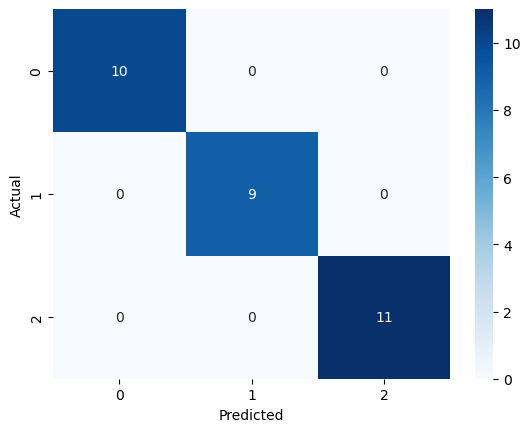

In [6]:
sns.heatmap(confusion_matrix(y_test , y_pred) , annot=True , cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")

## Regression on tips data 

In [7]:
 data  = sns.load_dataset("tips")
data.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [9]:
X = data.drop("tip" , axis=1)
y= data["tip"]
data.info

<bound method DataFrame.info of      total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]>

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder() 
for col in X.columns: 
    if X[col].dtype == "object" or X[col].dtype =="category":
        X[col] = le.fit_transform(X[col])

In [18]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split 
from sklearn.metrics import r2_score , root_mean_squared_error


X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42)

model = KNeighborsRegressor(n_neighbors=6 , metric="minkowski" , p=2)
model.fit(X_train , y_train)
y_pred = model.predict(X_test)

print("Root mean square error is " , root_mean_squared_error(y_test , y_pred))
print("r2 score  is " , r2_score(y_test , y_pred))




Root mean square error is  0.9312601184219506
r2 score  is  0.30618776866921593
